# Fig: LRD spectral gallery

Emergent $F_\lambda$ for the production grid: **columns** = mass-loss rate
$\dot M_{\rm out} = 2.5, 5, 10, 20\,M_\odot\,{\rm yr}^{-1}$; **rows** = wind family
(top: marginally-unbound `*_dilute_redd`; bottom: photon-tired `repro/ptf_m*`).
Smoothed continuum (1000 km/s boxcar), 45$^\circ$ observer (`A45P0.50`), log–log with
shared axes. Line IDs (Ly$\alpha$, C IV, He II, C III], H$\beta$, He I, H$\alpha$) and
the Balmer edge are marked on panel (a); a stronger $\dot M$ builds a stronger Balmer
break. The photon-tired m10/m20 panels use spectrum-only truncated reruns
(`*_hires_trunc_speconly`) and the marginally-unbound m20 panel the truncated hi-res
rerun (`1d_m20_dilute_redd_hires_trunc`): the spectrum is extracted from the converged
inner wind with the unconverged, photon-starved outer wind stripped.

In [5]:
import os
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d
from matplotlib.ticker import FixedLocator, FuncFormatter, NullFormatter

# ================= config: edit here to point at your data / output =================
# (self-contained per notebook for now; lift this block into a shared repro_paths.py
#  once the final matrix_pow + custom-band reruns exist and dirs are unified.)
DATA_ROOT = os.environ.get("SIROCCO_REPRO_DATA", "/scratch/gpfs/nk6352/sirocco_runs")
FIG_DIR   = os.path.abspath("../figures")           # where this notebook writes its PDF/PNG
RUN_SET   = os.environ.get("SIROCCO_REPRO_RUNSET", "repro")   # "legacy" (paper freeze) | "repro" (repro/ reruns)
# NOTE: repro/ runs = matrix_pow + Photon_sampling=wide. Photon-tired family = ptf_*
#   (f=0.94 tiring fraction, Gamma_0=1.2128 Owocki+2017 winds), superseding the legacy
#   g1.38 pt_* family; all four ptf runs completed & health-checked 2026-08-13.
#   ptf m10/m20 unconverged cells lie beyond the H recombination front (t_e collapse in
#   decoupled neutral gas; converged inside), so SPECTRA come from the *_trunc_speconly
#   extraction reruns where noted, while wind-structure tables read the parent dirs.
#   Verified 2026-08-11 against the legacy matrix_bb runs: mu_* AND pt_* are healthy
#   (the earlier matrix_pow pt_* under-ionization is gone; e.g. pt_m5 mid-wind h1~6e-4,
#   matching legacy ~5e-4). Integrated 2000-10000 A flux matches legacy to <~8% for all
#   runs except pt_m20 (0.42x the legacy g1.38_hires run; m20 is the known poorly-converged
#   case, and the gallery takes its m20 spectra from the *_trunc_speconly reruns).
RUN_DIRS_LEGACY  = {"mu_m2.5": "1d_m2.5_dilute_redd", "mu_m5": "1d_m5_dilute_redd",
             "mu_m10":  "1d_m10_dilute_redd",  "mu_m20": "1d_m20_dilute_redd_hires_trunc",
             "pt_m2.5": "photon_tired_winds/m2.5_g1.38_hires",
             "pt_m5":   "photon_tired_winds/m5_g1.38_hires",
             "pt_m10":  "photon_tired_winds/m10_g1.38_hires_trunc_speconly",
             "pt_m20":  "photon_tired_winds/m20_g1.38_hires_trunc_speconly"}
RUN_DIRS_REPRO = {"mu_m2.5": "repro/mu_m2.5", "mu_m5": "repro/mu_m5",
                   "mu_m10": "repro/mu_m10", "mu_m20": "repro/mu_m20_trunc_speconly",
                   "pt_m2.5": "repro/ptf_m2.5", "pt_m5": "repro/ptf_m5",
                   "pt_m10": "repro/ptf_m10", "pt_m20": "repro/ptf_m20_trunc_speconly"}
RUN_DIRS  = {"legacy": RUN_DIRS_LEGACY, "repro": RUN_DIRS_REPRO}[RUN_SET]
def run_path(k): return os.path.join(DATA_ROOT, RUN_DIRS[k])
os.makedirs(FIG_DIR, exist_ok=True)

# ---- manuscript style ----
plt.rcParams.update({
    'figure.dpi': 140, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'font.family': 'serif', 'mathtext.fontset': 'dejavuserif',
    'font.size': 9, 'axes.titlesize': 10, 'axes.labelsize': 10,
    'axes.linewidth': 0.8, 'lines.linewidth': 1.0,
    'xtick.direction': 'in', 'ytick.direction': 'in',
    'xtick.top': True, 'ytick.right': True,
    'xtick.minor.visible': True, 'ytick.minor.visible': True,
})
# ====================================================================================

C_KMS      = 299792.458    # km/s
OBS_COL    = 'A45P0.50'    # 45-deg observer column in outflow.log_spec
SMOOTH_KMS = 1000.0        # boxcar FWHM for the smoothed continuum
XLIM       = (0.09, 1.0)   # microns
XTICKS     = [0.1, 0.2, 0.3, 0.5, 1.0]


def log_spec_path(key):
    """Path to a run's log_spec, handling both the standard 'outflow' root and the
    'spec' root used by spectrum-only (System_type=previous) truncated reruns."""
    base = run_path(key)
    for root in ('outflow', 'spec'):
        p = f'{base}/{root}.log_spec'
        if os.path.exists(p):
            return p
    return f'{base}/outflow.log_spec'   # default -> clear FileNotFoundError if truly missing


def smoothed_spectrum(key):
    """lambda [um] and boxcar-smoothed F_lambda (SMOOTH_KMS FWHM), sorted blue->red."""
    s   = pd.read_csv(log_spec_path(key), sep=r'\s+', comment='#')
    lam = s['Lambda'].to_numpy() / 1e4                    # AA -> um
    nu  = s['Freq.'].to_numpy()
    dv  = C_KMS * np.median(np.abs(np.diff(np.log(nu))))  # km/s per pixel (log-uniform)
    fl  = uniform_filter1d(s[OBS_COL].to_numpy(), size=max(1, round(SMOOTH_KMS / dv)))
    o   = np.argsort(lam)
    return lam[o], fl[o]

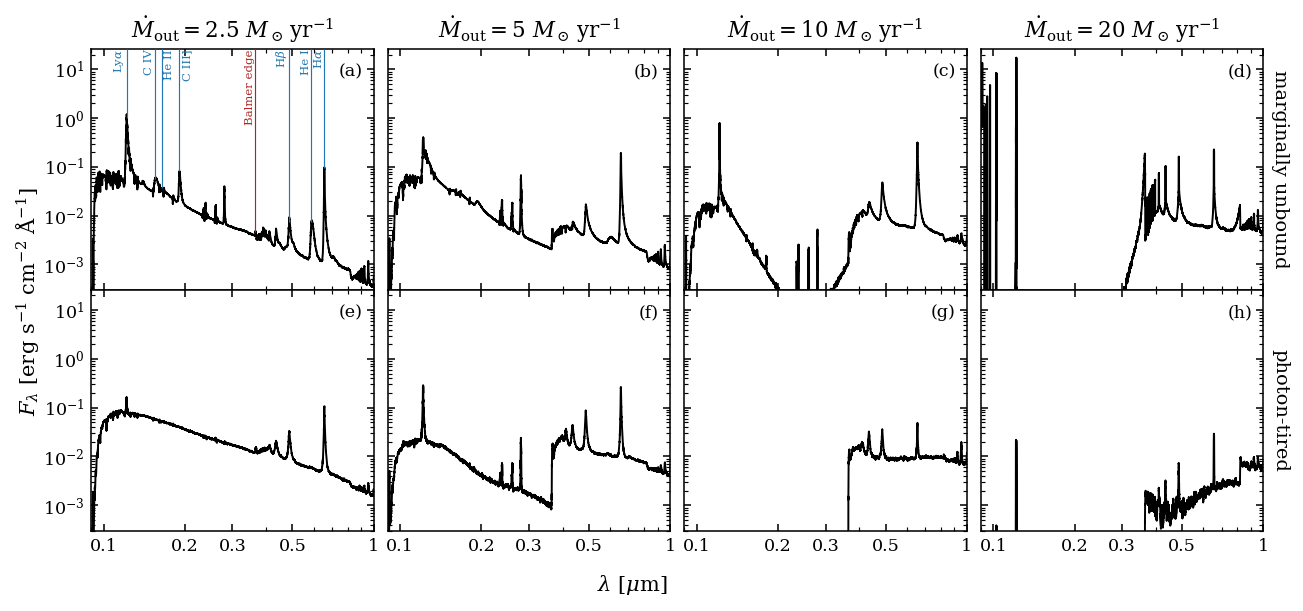

In [6]:
# ===== 2x4 spectral gallery: columns = Mdot, rows = wind family =====
# Same smoothed F_lambda (1000 km/s boxcar, 45-deg observer A45P0.50) laid out by mass-loss rate.
#   rows: mu = marginally-unbound (*_dilute_redd) ; pt = photon-tired (repro/ptf_m*, f=0.94)
#   cols: Mdot = 2.5, 5, 10, 20 Msun/yr
#   mu_m20 uses the truncated hi-res rerun; pt_m10 / pt_m20 the spectrum-only truncated reruns.
MDOTS  = [2.5, 5, 10, 20]
GRID_M = [['mu_m2.5', 'mu_m5', 'mu_m10', 'mu_m20'],
          ['pt_m2.5', 'pt_m5', 'pt_m10', 'pt_m20']]

dataM  = [[smoothed_spectrum(k) for k in row] for row in GRID_M]
inwinM = [f[(l >= XLIM[0]) & (l <= XLIM[1])] for row in dataM for l, f in row]
ylimM  = (3e-4, 1.5 * max(f.max() for f in inwinM))     # common y-range; floor clips starved UV

figM, axesM = plt.subplots(2, 4, figsize=(9.2, 4.3), sharex=True, sharey=True)
figM.subplots_adjust(left=0.08, right=0.99, top=0.92, bottom=0.12, hspace=0, wspace=0.05)
lettersM = iter('abcdefgh')

for i, row in enumerate(GRID_M):
    for j, key in enumerate(row):
        ax = axesM[i, j]
        ax.plot(*dataM[i][j], color='k')
        ax.text(0.96, 0.94, f'({next(lettersM)})', transform=ax.transAxes, va='top', ha='right')
        if i == 0:
            ax.set_title(rf'$\dot{{M}}_{{\rm out}} = {MDOTS[j]:g}\ M_\odot\,\mathrm{{yr}}^{{-1}}$', fontsize=11)

axesM[0, 0].set(xscale='log', yscale='log', xlim=XLIM, ylim=ylimM)
for j in range(4):                                     # clean ticks; blank leading 0.1 on inner cols
    fmt = FuncFormatter(lambda x, _, c=j: '' if (c and np.isclose(x, XLIM[0])) else f'{x:g}')
    for ax in axesM[:, j]:
        ax.xaxis.set_major_locator(FixedLocator(XTICKS))
        ax.xaxis.set_major_formatter(fmt)
        ax.xaxis.set_minor_formatter(NullFormatter())

# ---- line-ID markers on panel (a) only (panel a = mu_m2.5) ----
# vertical stem from the curve up to the panel top; rotated label to the LEFT of each line,
# except C III] and He II which go RIGHT (He II's left label was being clipped by C IV).
ax_a        = axesM[0, 0]
lam_a, fl_a = dataM[0][0]
LINES = [(0.121567, r'Ly$\alpha$', 'tab:blue'), (0.154905, 'C IV', 'tab:blue'),
         (0.164040, 'He II', 'tab:blue'),        (0.190870, 'C III]', 'tab:blue'),
         (0.486133, r'H$\beta$', 'tab:blue'),     (0.587600, 'He I', 'tab:blue'),
         (0.656280, r'H$\alpha$', 'tab:blue'),    (0.364600, 'Balmer edge', 'firebrick')]
RIGHT_LABEL = {0.190870, 0.164040}                      # C III] and He II: label to the RIGHT of the line
ytopM = ylimM[1]
for wl, nm, col in LINES:
    if not (XLIM[0] <= wl <= XLIM[1]):
        continue
    y0 = np.interp(wl, lam_a, fl_a)
    ax_a.vlines(wl, y0, ytopM, color=col, lw=0.6, zorder=5)
    right = wl in RIGHT_LABEL
    ax_a.text(wl * (1.02 if right else 0.995), ytopM, nm, rotation=90, rotation_mode='anchor',
              ha='right', va=('top' if right else 'bottom'), color=col, fontsize=6, zorder=6)

axesM[0, -1].text(1.06, 0.5, 'marginally unbound', transform=axesM[0, -1].transAxes, rotation=270,
                  va='center', ha='center', color='k', fontsize=10)
axesM[1, -1].text(1.06, 0.5, 'photon-tired', transform=axesM[1, -1].transAxes, rotation=270,
                  va='center', ha='center', color='k', fontsize=10)

figM.supxlabel(r'$\lambda\ [\mu\mathrm{m}]$')
figM.supylabel(r'$F_\lambda\ [\mathrm{erg\ s^{-1}\ cm^{-2}\ \AA^{-1}}]$')
figM.savefig(os.path.join(FIG_DIR, 'Fig_LRD_gallery.pdf'))
figM.savefig(os.path.join(FIG_DIR, 'Fig_LRD_gallery.png'), dpi=300)
plt.show()